# Data Exploration of Subset 
It includes patients with followup FVC after 1 year +- 1 month and baseline HRCT and FVC.

In [1]:
import pandas as pd


### Load Dataframe of the subset Yash Saved on the HPC

In [2]:
patient_with_followup_yash = pd.read_csv('../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUCTURE_MAIN/Patients_with_followup_48_56.csv')
crf_filtered_yash = pd.read_csv('../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUCTURE_MAIN/Merge_CRF_fill_filtered.csv')

In [3]:
crf_filtered_yash['Subject ID'].nunique()

686

In [4]:
Patient_IDs = set(patient_with_followup_yash['Subject ID'])
len(Patient_IDs)
#Patient used by Yash

575

In [5]:
patient_df = pd.read_csv('./df_patient_late_followup_extra.csv', index_col=False)
patient_df = patient_df[patient_df['Subject ID'].isin(Patient_IDs)]

In [6]:
patient_df['Subject ID'].nunique()

575

####  Compare columns of Yash's datafram and our patient dataframe


In [7]:
set(patient_with_followup_yash.columns) - set(patient_df.columns)
# Columns used by Yash but not in our dataframe:

{'Baseline Acquisition Date',
 'Baseline FVC DATE',
 'Baseline FVC Predicted %',
 'Baseline FVC Volume L',
 'Baseline FVC Week',
 'Baseline SeriesInstanceUID',
 'Delta FVC',
 'Followup Acquisition Date',
 'Followup FVC DATE',
 'Followup FVC Predicted %',
 'Followup FVC Volume L',
 'Followup FVC Week',
 'Followup SeriesInstanceUID'}

In [8]:
set(patient_df.columns)-set(patient_with_followup_yash.columns)


{'Age',
 'Antifibrotic therapy Treatment Performed',
 'Cause of Death',
 'Cough',
 'DLCO CAP(Not Adjusted)',
 'DLCO DATE(Not Adjusted)',
 'DLCO(Not Adjusted) Predicted %',
 'Deceased',
 'Dyspnea',
 'Ethnicity',
 'FVC DATE',
 'FVC Predicted %',
 'FVC Volume L',
 'FVC Week',
 'Familial Pulm Fibrosis',
 'Finger Clubbing',
 'First Acquisition Date',
 'General Therapy Treatment Performed',
 'Home Region',
 'ImmunomodulationTherepy Treatment Performed',
 'Race',
 'Research : Height',
 'Risk Environmental',
 'Risk Occupational Description',
 'Risk Precipitins',
 'Secondary Diagnosis',
 'Smoking History',
 'Smoking Pack Years',
 'Smoking Stop Date',
 'Type CTD',
 'Velcro Crackles',
 'Week FVC First Acquisition'}

In [9]:
set(patient_df.columns)-set(crf_filtered_yash.columns)

{'FVC Week', 'First Acquisition Date', 'Week FVC First Acquisition'}

In [10]:
set(crf_filtered_yash.columns)- set(patient_df.columns)

{'%BAL Eosinophils',
 '%BAL Lymphocytes',
 '%BAL Macrophages',
 '%BAL Neutrophils',
 '6MWT Date',
 'Antifibrotic therapy  Description',
 'Antifibrotic therapy Additional Information',
 'Antifibrotic therapy End Date',
 'Antifibrotic therapy Start Date',
 'Approx. Exacerbation date',
 'Approx. Symptoms start',
 'Associated Autoantibodies',
 'Associated Autoantibodies Description',
 'BORG Scale',
 'Broncho Lavage Available',
 'Change Log',
 'DLCO CAP(Adjusted)',
 'DLCO DATE(Adjusted)',
 'DLCO(Adjusted) Predicted %',
 'Date Of Transplant',
 'Date of BAL',
 'Date of CTD Diagnosis',
 'Date of Diagnosis',
 'Distance',
 'Exacerbation',
 'FEV1 Predicted %',
 'FEV1 Volume L',
 'General Therapy  Description',
 'General Therapy Additional Information',
 'General Therapy End Date',
 'General Therapy Start Date',
 'ImmunomodulationTherepy  Description',
 'ImmunomodulationTherepy Additional Information',
 'ImmunomodulationTherepy End Date',
 'ImmunomodulationTherepy Start Date',
 'Informer',
 'Last 

### NaN Check in both dataframes

In [11]:
nan_counts = patient_df.isnull().sum()
print("NaN counts per column:")
print(nan_counts.sort_values(ascending=True).head(30))  

NaN counts per column:
Subject ID                                       0
FVC DATE                                         0
Ethnicity                                        0
FVC Volume L                                     0
Race                                             0
Home Region                                      0
Sex                                              0
Deceased                                         0
Primary Diagnosis                                0
Week FVC First Acquisition                       0
First Acquisition Date                           0
FVC Week                                         0
Research : Height                                2
FVC Predicted %                                  4
Smoking History                                 20
Type CTD                                        46
ImmunomodulationTherepy Treatment Performed     57
General Therapy Treatment Performed             57
Antifibrotic therapy Treatment Performed        57
Familial

In [12]:
# Filter crf_filtered_yash to keep only columns present in patient_df for better comparaison
column_emma = patient_df.columns.intersection(crf_filtered_yash.columns)
crf_filtered_yash_reduce = crf_filtered_yash[column_emma]

In [13]:
nan_counts_yash_raw = crf_filtered_yash_reduce.isnull().sum()
print("NaN counts per column:")
print(nan_counts_yash_raw.sort_values(ascending=True).head(20))

NaN counts per column:
Subject ID                                        0
Home Region                                       0
Race                                              0
Ethnicity                                         0
Sex                                               0
Deceased                                          0
Primary Diagnosis                                 0
FVC DATE                                          2
FVC Volume L                                      2
Research : Height                                 3
FVC Predicted %                                  10
Smoking History                                  26
ImmunomodulationTherepy Treatment Performed     190
General Therapy Treatment Performed             190
Antifibrotic therapy Treatment Performed        190
DLCO DATE(Not Adjusted)                         721
DLCO CAP(Not Adjusted)                          725
Age                                            1268
Smoking Pack Years                       

In [14]:
nan_counts_yash = patient_with_followup_yash.isnull().sum()
print("NaN counts per column:")
print(nan_counts_yash.sort_values(ascending=False))

NaN counts per column:
Followup SeriesInstanceUID    416
Followup Acquisition Date     416
Baseline FVC Predicted %        2
Followup FVC Predicted %        2
Baseline FVC Week               0
Subject ID                      0
Baseline FVC DATE               0
Baseline FVC Volume L           0
Followup FVC DATE               0
Baseline SeriesInstanceUID      0
Baseline Acquisition Date       0
Followup FVC Volume L           0
Followup FVC Week               0
Primary Diagnosis               0
Sex                             0
Delta FVC                       0
dtype: int64


## Visualization of categorial variables

In [15]:
import matplotlib.pyplot as plt
import numpy as np

### Data Preprocessing for Visualization

In [16]:
# change No Information and None to NaN

patient_df = patient_df.replace({None: np.nan})
patient_df = patient_df.replace('No Information', np.nan)
patient_df = patient_df.replace('No information', np.nan)
patient_df = patient_df.replace('No Knowledge', np.nan)

In [17]:
unique_patient_df = patient_df.groupby('Subject ID').first()

In [18]:
# recheck nan counts
nan_counts_unique = unique_patient_df.isnull().sum()
print("NaN counts per column after cleaning:")
print(nan_counts_unique.sort_values(ascending=True))

NaN counts per column after cleaning:
Age                                              0
FVC Predicted %                                  0
FVC DATE                                         0
FVC Volume L                                     0
Sex                                              0
Home Region                                      0
FVC Week                                         0
Deceased                                         0
Week FVC First Acquisition                       0
First Acquisition Date                           0
Research : Height                                1
Primary Diagnosis                                3
Smoking History                                 20
Type CTD                                        29
DLCO DATE(Not Adjusted)                        187
DLCO CAP(Not Adjusted)                         188
Familial Pulm Fibrosis                         236
Ethnicity                                      282
DLCO(Not Adjusted) Predicted %              

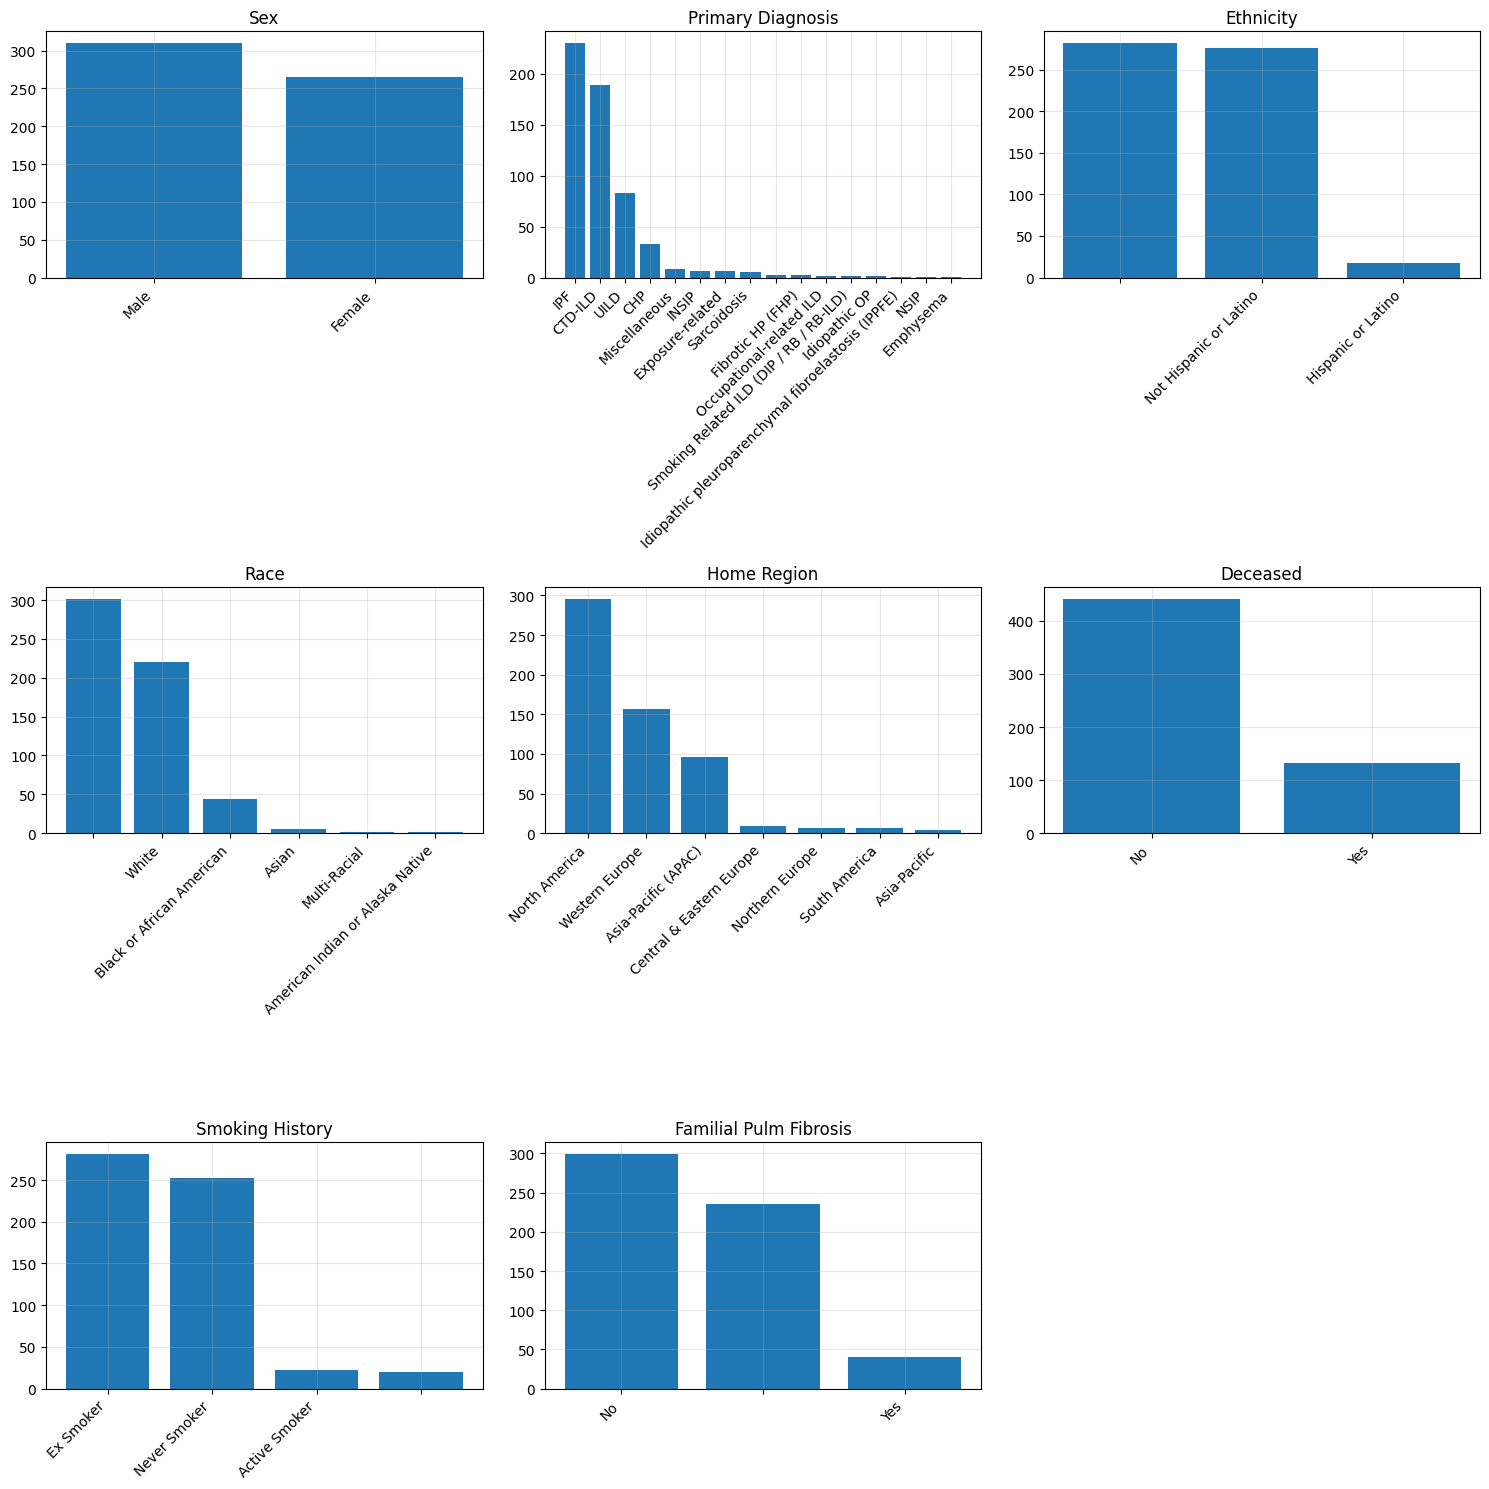

In [19]:
# Create visualizations for categorical variables
categorical_vars = ['Sex', 'Primary Diagnosis', 'Ethnicity', 'Race', 'Home Region', 'Deceased', 'Smoking History','Familial Pulm Fibrosis']

# Set up the plotting layout
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    if i < len(axes):
        # Get value counts and plot
        value_counts = unique_patient_df[var].value_counts(dropna=False)
        axes[i].bar(range(len(value_counts)), value_counts.values)
        axes[i].set_title(f'{var}')
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

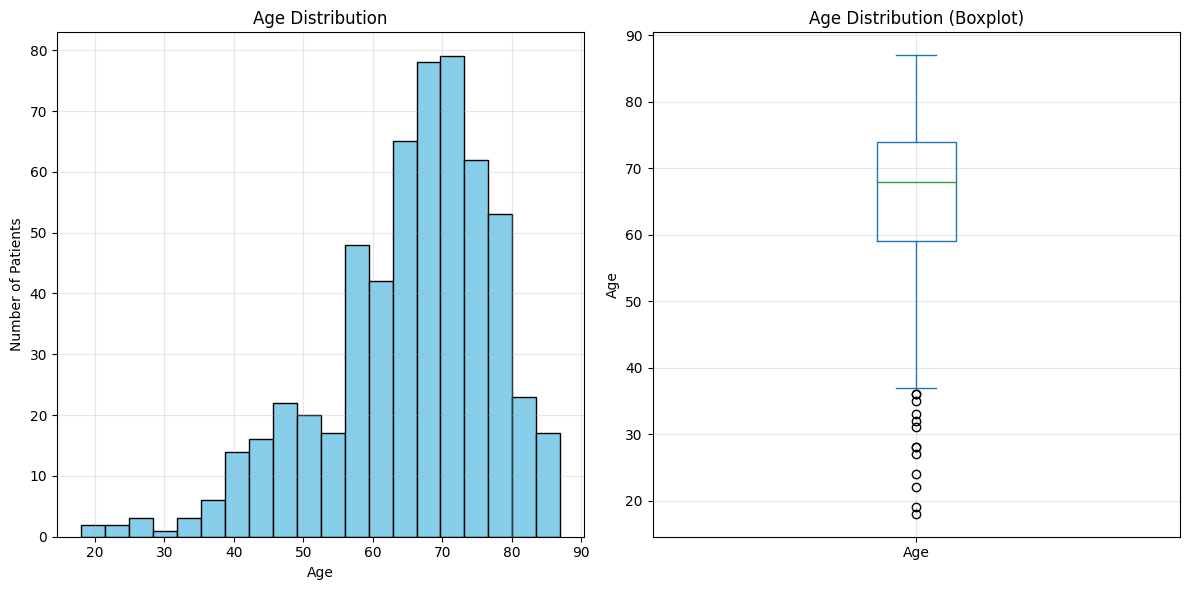

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Convert Age to numeric, handling None values
age_numeric = pd.to_numeric(unique_patient_df['Age'], errors='coerce')

# Age histogram
age_numeric.hist(bins=20, color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title('Age Distribution')
ax1.set_xlabel('Age')
ax1.set_ylabel('Number of Patients')
ax1.grid(True, alpha=0.3)

# Age boxplot
age_numeric.plot.box(ax=ax2)
ax2.set_title('Age Distribution (Boxplot)')
ax2.set_ylabel('Age')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Soll ich hier bei Na
unique_patient_df[['Primary Diagnosis','Type CTD']].value_counts(dropna=False)

Primary Diagnosis                                    Type CTD      
IPF                                                  Other             111
                                                     Not Applicable     99
UILD                                                 Not Applicable     61
CTD-ILD                                              Other              52
                                                     SSc                44
                                                     RA                 30
                                                     PM/DM              26
CHP                                                  Other              22
IPF                                                  NaN                20
UILD                                                 Other              19
CTD-ILD                                              SS                 14
                                                     MCTD               13
CHP                             

Other (214) – Cases where the CTD type is known but doesn’t fit into the main categories. \
Not Applicable (196) – Patients without a CTD diagnosis (likely idiopathic ILD). \
SSc (44) – Systemic Sclerosis (also called scleroderma). \
RA (30) – Rheumatoid Arthritis. \
NaN (29) – Missing data (no information recorded). -> Should I correct it if I know the disease is not CTD related? \
PM/DM (26) – Polymyositis/Dermatomyositis (inflammatory myopathies). \
MCTD (14) – Mixed Connective Tissue Disease. \
SS (14) – Sjögren’s Syndrome.\
SLE (8) – Systemic Lupus Erythematosus

### Treatment Insights

In [22]:
treatment_columns = ['Antifibrotic therapy Treatment Performed',
                     'ImmunomodulationTherepy Treatment Performed',
                     'General Therapy Treatment Performed']

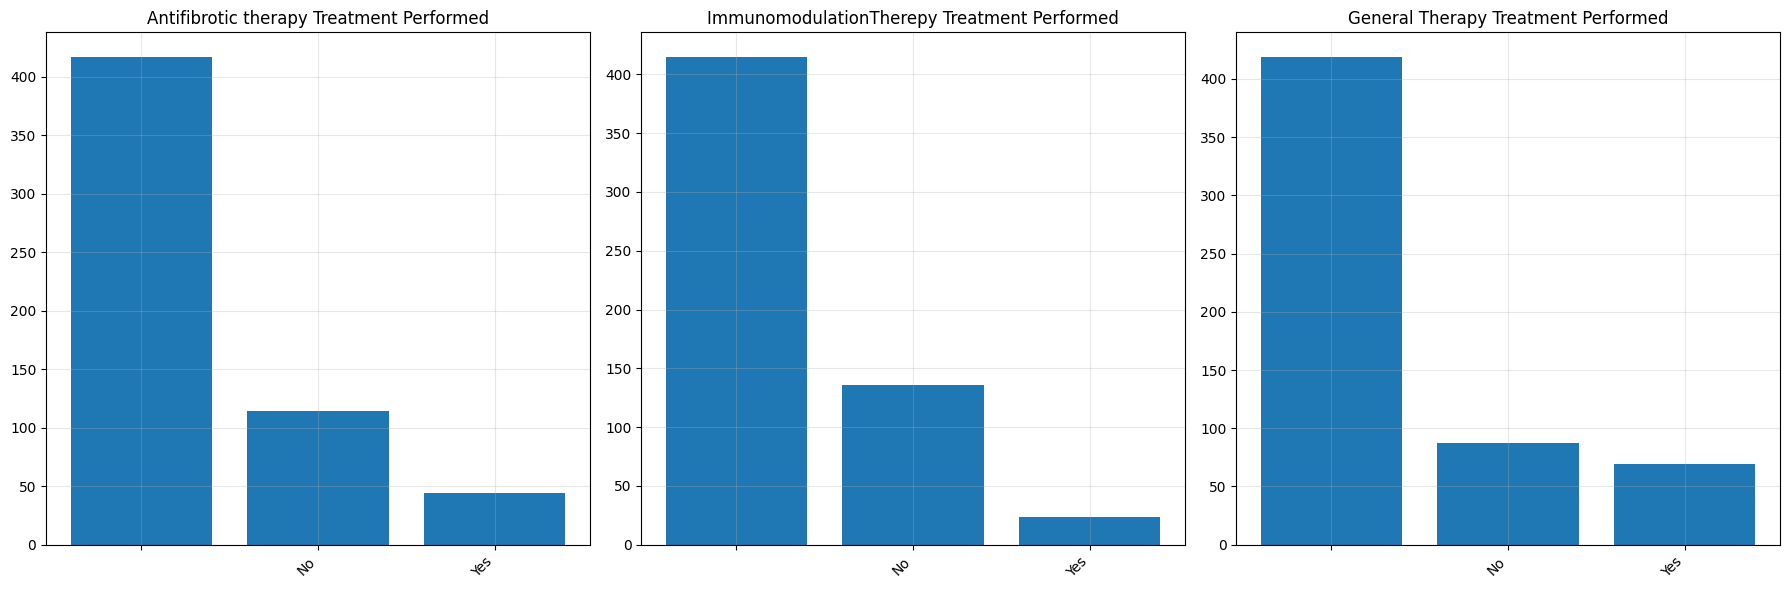

In [23]:
# Treatment types visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(treatment_columns):
    value_counts = unique_patient_df[col].value_counts(dropna=False)
    axes[i].bar(range(len(value_counts)), value_counts.values)
    axes[i].set_title(f'{col}')
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
unique_patient_df[['Antifibrotic therapy Treatment Performed',
            'ImmunomodulationTherepy Treatment Performed',
            'General Therapy Treatment Performed']].value_counts(dropna=False)

Antifibrotic therapy Treatment Performed  ImmunomodulationTherepy Treatment Performed  General Therapy Treatment Performed
NaN                                       NaN                                          NaN                                    415
No                                        No                                           No                                      51
                                                                                       Yes                                     41
Yes                                       No                                           No                                      32
No                                        Yes                                          Yes                                     17
Yes                                       No                                           Yes                                      9
No                                        Yes                                          No        

#### Preprocessing - Separate baseline from followup FVC values

In [25]:
# filtered FVC Predicted at baseline
patient_df_baseline = patient_df[patient_df.set_index('Subject ID')['Week FVC First Acquisition'].between(-5, 5).values]
# take value the closest to week 0 if multiple available
patient_df_baseline = patient_df_baseline.sort_values(by=['Subject ID', 'Week FVC First Acquisition'], key=lambda x: x.abs() if x.name == 'Week FVC First Acquisition' else x)
patient_df_baseline = patient_df_baseline.groupby('Subject ID').first()

# FVC Predicted follow-up at week 52 +- 4 weeks from baseline
patient_df_followup = patient_df.copy()
# Calculate followup week range relative to each patient's baseline week
baseline_weeks = patient_df_baseline.reset_index().set_index('Subject ID')['Week FVC First Acquisition']
patient_df_followup = patient_df_followup.merge(baseline_weeks.rename('Baseline Week'), left_on='Subject ID', right_index=True, how='left')
# Filter for followup within 52 ± 4 weeks from each patient's baseline
patient_df_followup = patient_df_followup[
    (patient_df_followup['Week FVC First Acquisition'] >= patient_df_followup['Baseline Week'] + 48) &
    (patient_df_followup['Week FVC First Acquisition'] <= patient_df_followup['Baseline Week'] + 56)
]
# Take value closest to baseline + 52 weeks if multiple available
patient_df_followup['Distance_from_target'] = abs(patient_df_followup['Week FVC First Acquisition'] - (patient_df_followup['Baseline Week'] + 52))
patient_df_followup = patient_df_followup.sort_values(['Subject ID', 'Distance_from_target'])
patient_df_followup = patient_df_followup.groupby('Subject ID').first()
# Clean up helper columns
patient_df_followup = patient_df_followup.drop(['Baseline Week', 'Distance_from_target'], axis=1)


In [26]:
patient_df_baseline['Week FVC First Acquisition'].value_counts()

Week FVC First Acquisition
 0    531
 1     17
 2     14
-1      7
-2      5
 4      1
Name: count, dtype: int64

In [27]:
patient_df_followup['Week FVC First Acquisition'].value_counts()

Week FVC First Acquisition
48    132
52     95
54     60
51     54
50     54
53     53
55     46
56     46
49     30
57      2
58      2
60      1
Name: count, dtype: int64

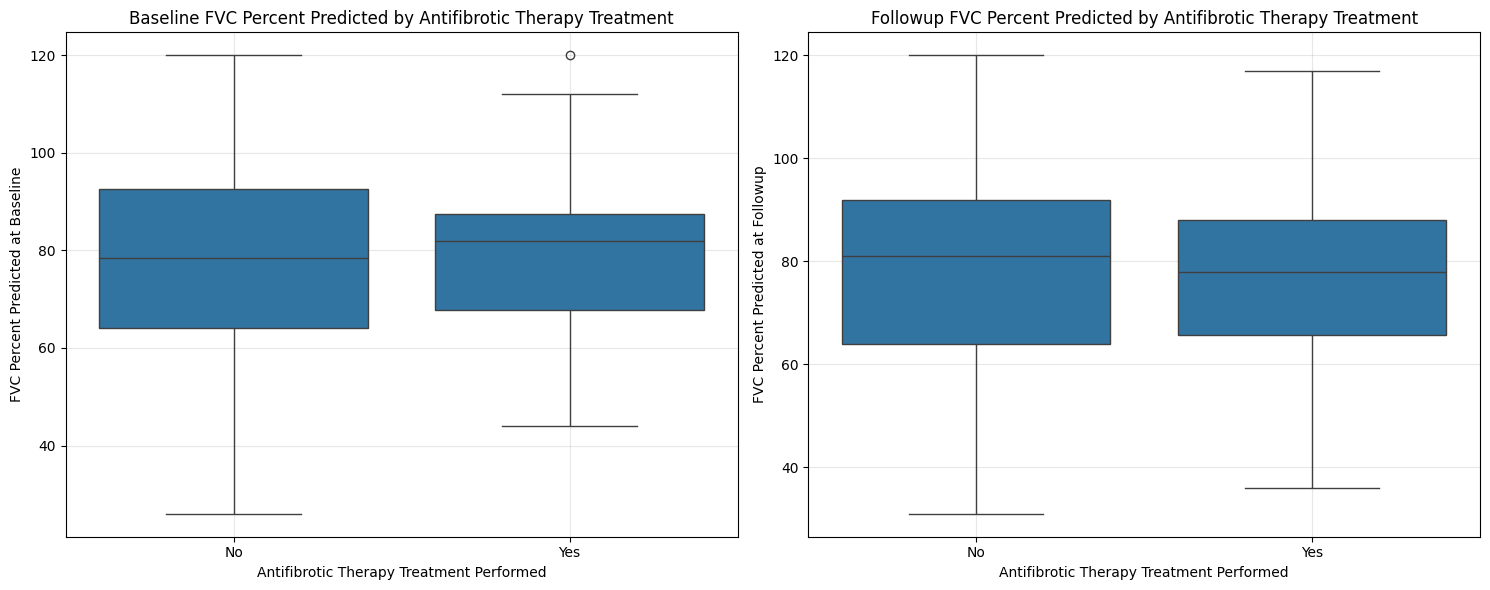

In [28]:
# box plots FVC predicted of patient with treatment vs no treatment at baseline and follow up
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Baseline FVC by treatment status
sns.boxplot(x='Antifibrotic therapy Treatment Performed', y='FVC Predicted %', 
           data=patient_df_baseline.reset_index(), ax=axes[0])
axes[0].set_title('Baseline FVC Percent Predicted by Antifibrotic Therapy Treatment')
axes[0].set_xlabel('Antifibrotic Therapy Treatment Performed')
axes[0].set_ylabel('FVC Percent Predicted at Baseline')
axes[0].grid(True, alpha=0.3)

# Followup FVC by treatment status  
sns.boxplot(x='Antifibrotic therapy Treatment Performed', y='FVC Predicted %', 
           data=patient_df_followup.reset_index(), ax=axes[1])
axes[1].set_title('Followup FVC Percent Predicted by Antifibrotic Therapy Treatment')
axes[1].set_xlabel('Antifibrotic Therapy Treatment Performed')
axes[1].set_ylabel('FVC Percent Predicted at Followup')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

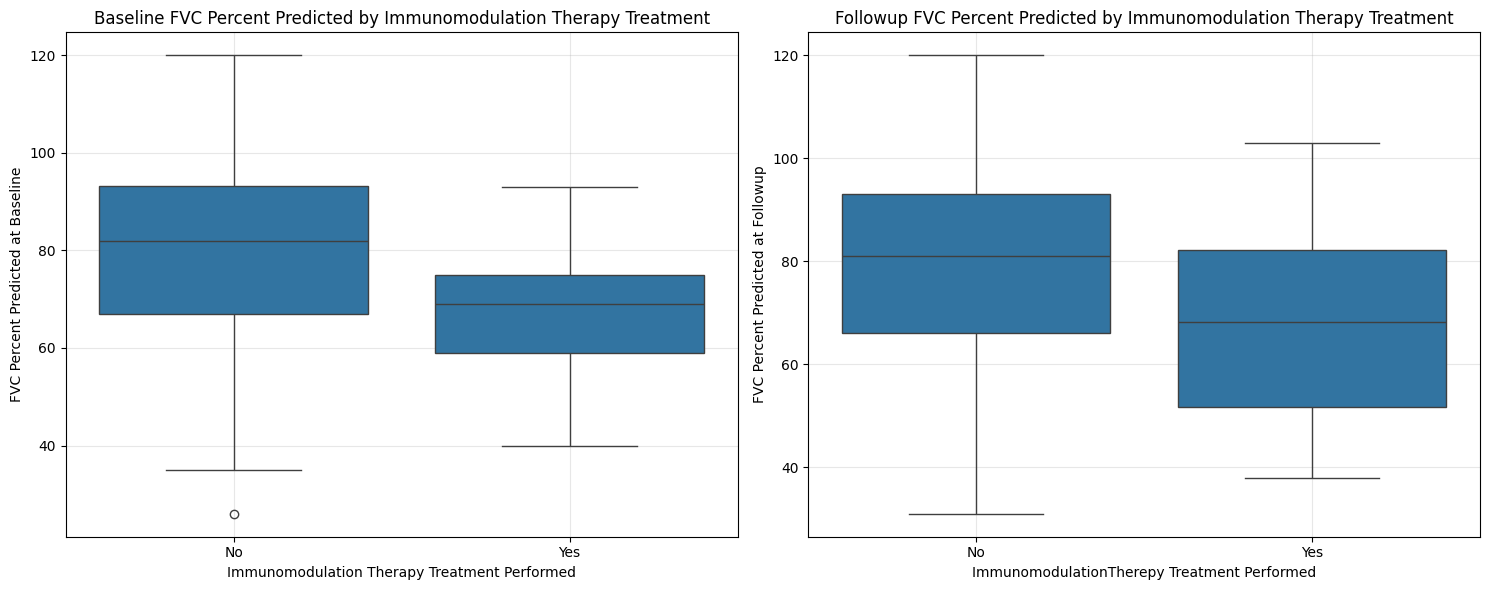

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Baseline FVC by treatment status
sns.boxplot(x='ImmunomodulationTherepy Treatment Performed', y='FVC Predicted %', 
           data=patient_df_baseline.reset_index(), ax=axes[0])
axes[0].set_title('Baseline FVC Percent Predicted by Immunomodulation Therapy Treatment')
axes[0].set_xlabel('Immunomodulation Therapy Treatment Performed')
axes[0].set_ylabel('FVC Percent Predicted at Baseline')
axes[0].grid(True, alpha=0.3)

# Followup FVC by treatment status  
sns.boxplot(x='ImmunomodulationTherepy Treatment Performed', y='FVC Predicted %', 
           data=patient_df_followup.reset_index(), ax=axes[1])
axes[1].set_title('Followup FVC Percent Predicted by Immunomodulation Therapy Treatment')
axes[1].set_xlabel('ImmunomodulationTherepy Treatment Performed')
axes[1].set_ylabel('FVC Percent Predicted at Followup')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

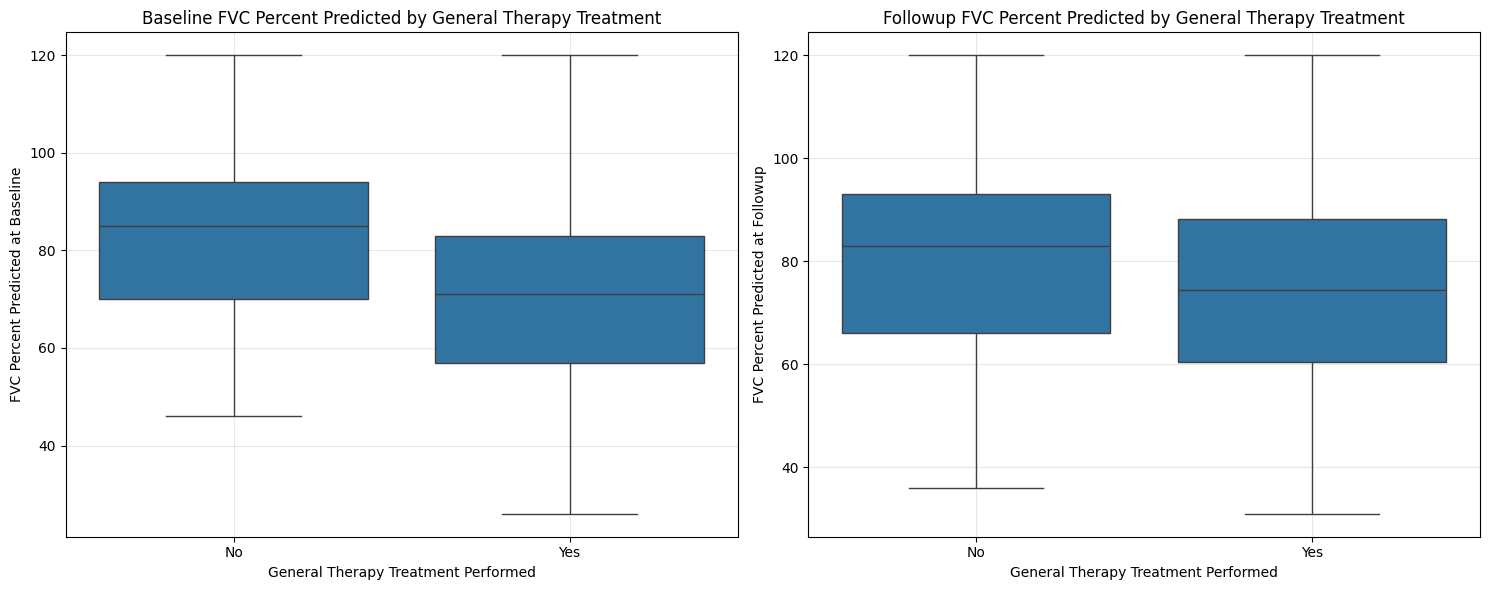

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Baseline FVC by treatment status
sns.boxplot(x='General Therapy Treatment Performed', y='FVC Predicted %', 
           data=patient_df_baseline.reset_index(), ax=axes[0])
axes[0].set_title('Baseline FVC Percent Predicted by General Therapy Treatment')
axes[0].set_xlabel('General Therapy Treatment Performed')
axes[0].set_ylabel('FVC Percent Predicted at Baseline')
axes[0].grid(True, alpha=0.3)

# Followup FVC by treatment status  
sns.boxplot(x='General Therapy Treatment Performed', y='FVC Predicted %', 
           data=patient_df_followup.reset_index(), ax=axes[1])
axes[1].set_title('Followup FVC Percent Predicted by General Therapy Treatment')
axes[1].set_xlabel('General Therapy Treatment Performed')
axes[1].set_ylabel('FVC Percent Predicted at Followup')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Symptom Insights

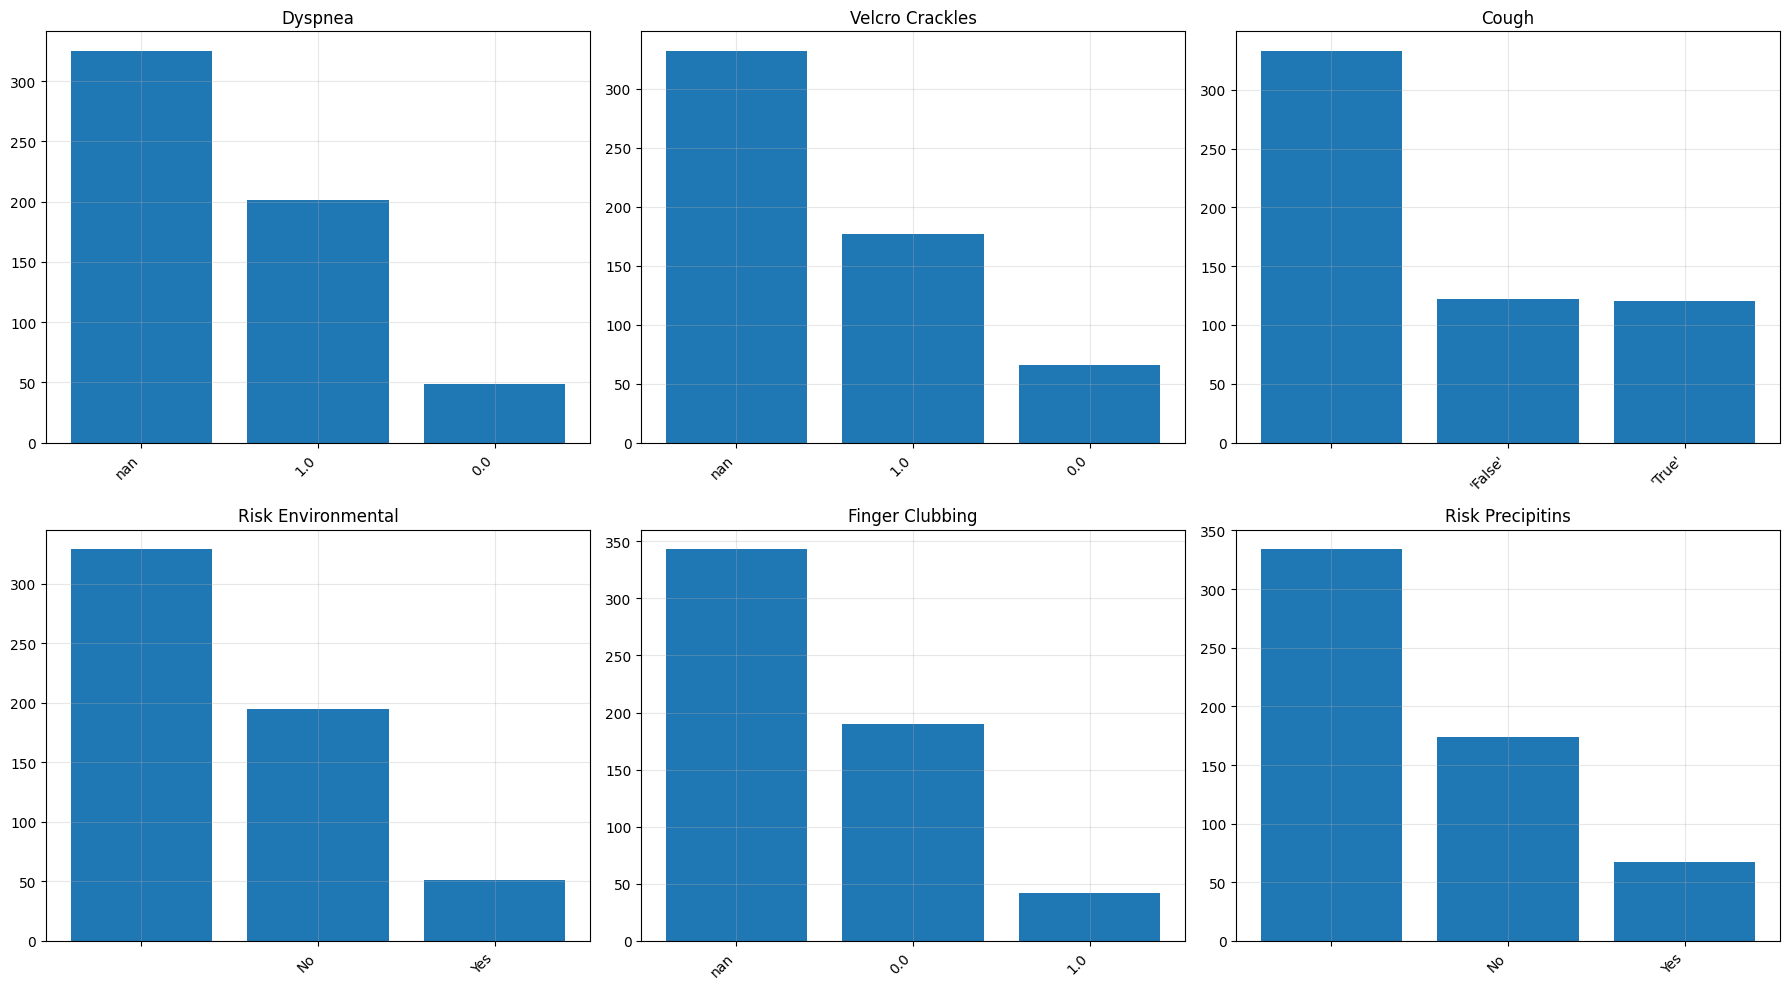

In [31]:
# Symptomes visualization
symptom_columns = ['Dyspnea', 'Velcro Crackles', 'Cough', 'Risk Environmental', 'Finger Clubbing', 'Risk Precipitins']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()   
for i, col in enumerate(symptom_columns):
    value_counts = unique_patient_df[col].value_counts(dropna=False)
    axes[i].bar(range(len(value_counts)), value_counts.values)
    axes[i].set_title(f'{col}')
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Distribution of continuous variables

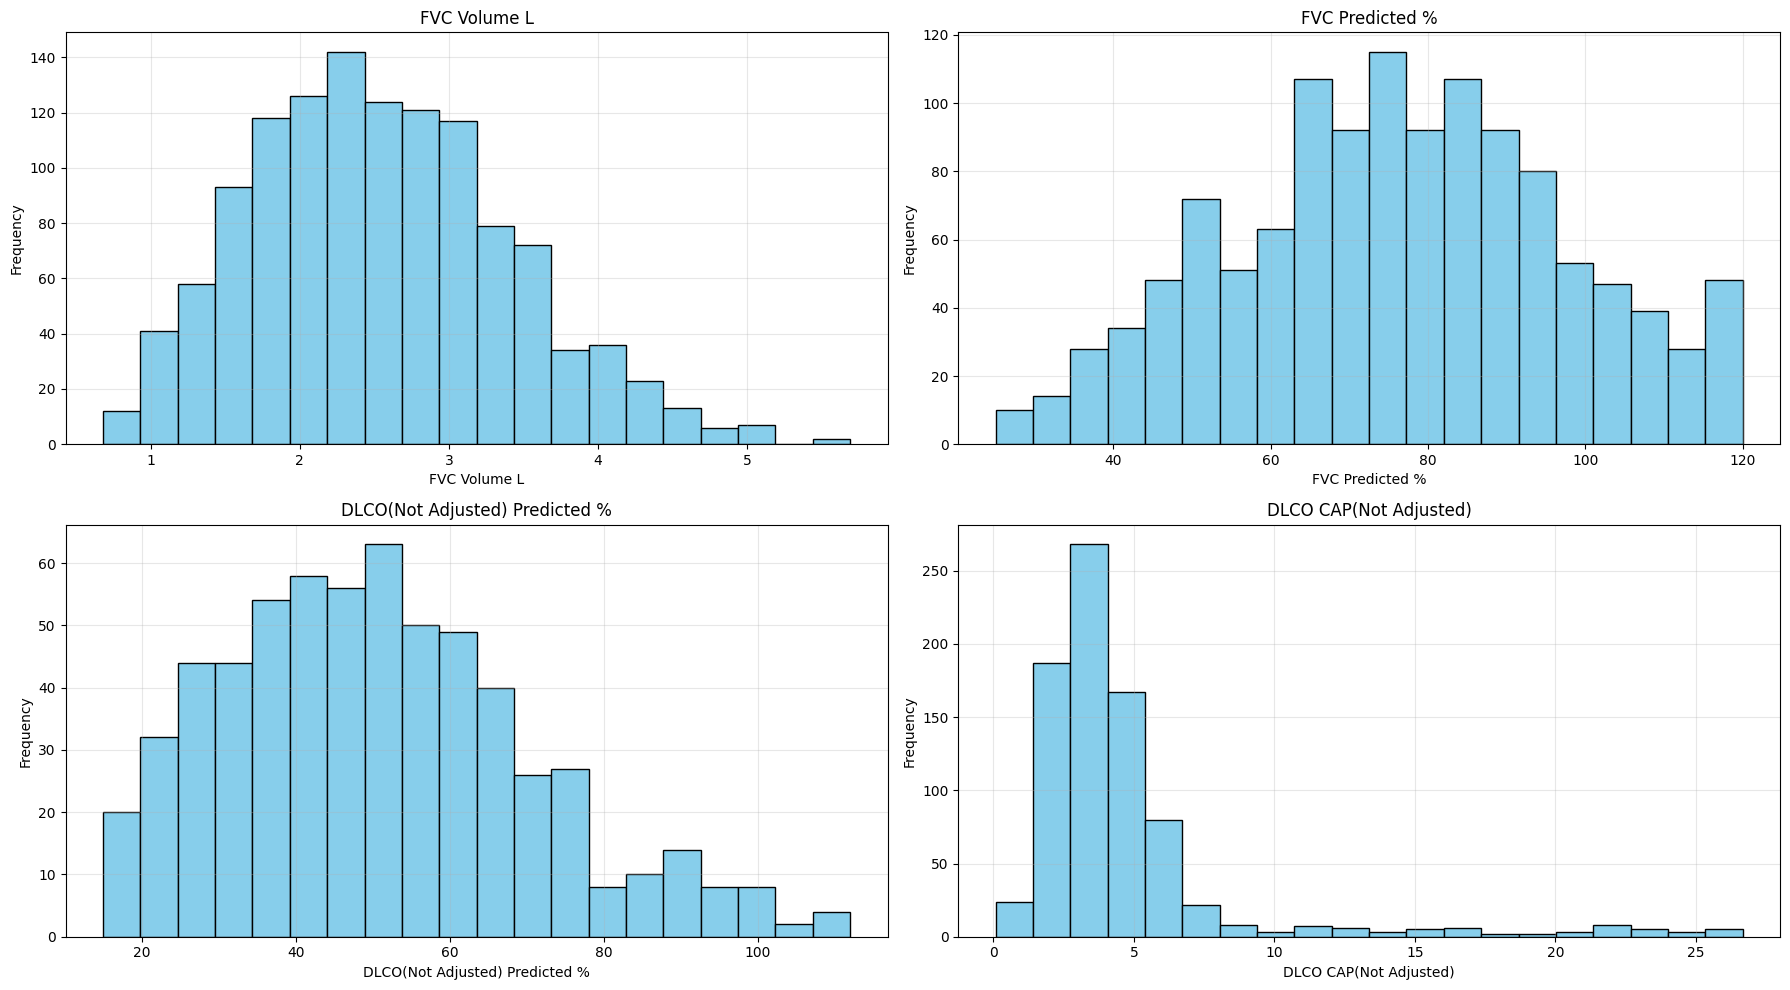

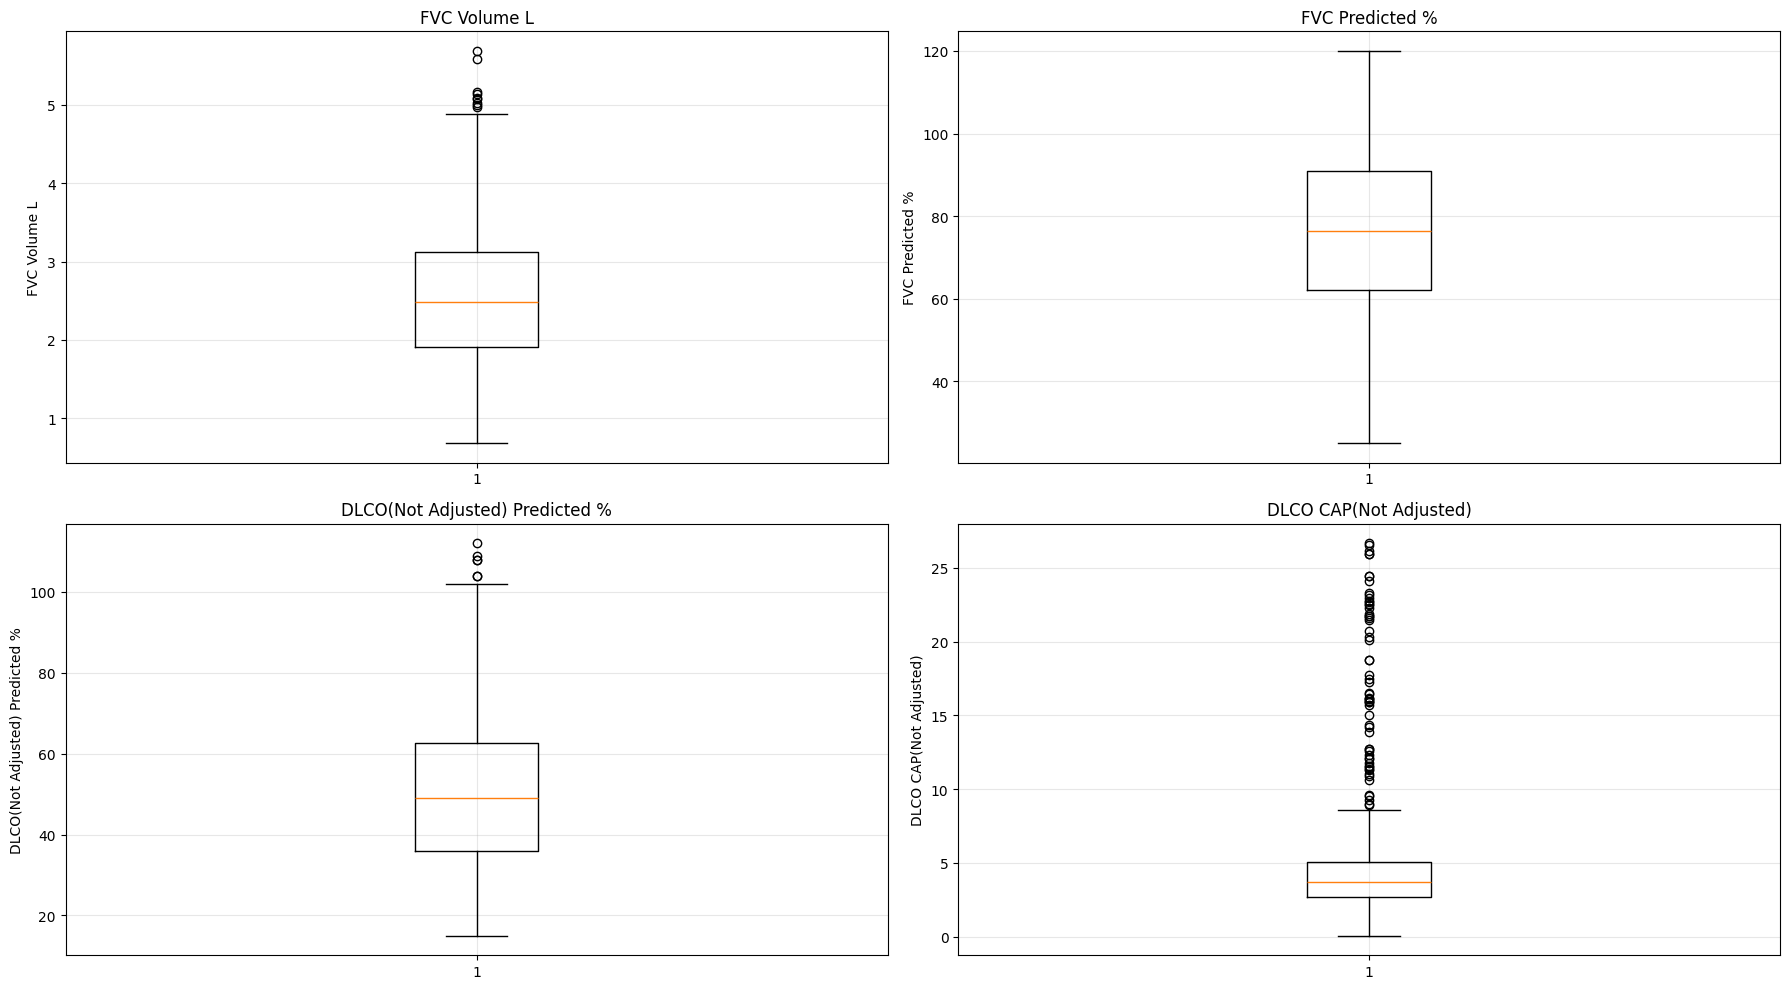

In [32]:
continuous_columns = ['FVC Volume L', 'FVC Predicted %', 'DLCO(Not Adjusted) Predicted %', 'DLCO CAP(Not Adjusted)']

# Convert 'DLCO DATE(Not Adjusted)' to datetime
patient_df['DLCO DATE(Not Adjusted)'] = pd.to_datetime(patient_df['DLCO DATE(Not Adjusted)'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(continuous_columns):
    axes[i].hist(patient_df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()  

# box plots for continuous variables
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(continuous_columns):    
    axes[i].boxplot(patient_df[col].dropna(), vert=True)
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

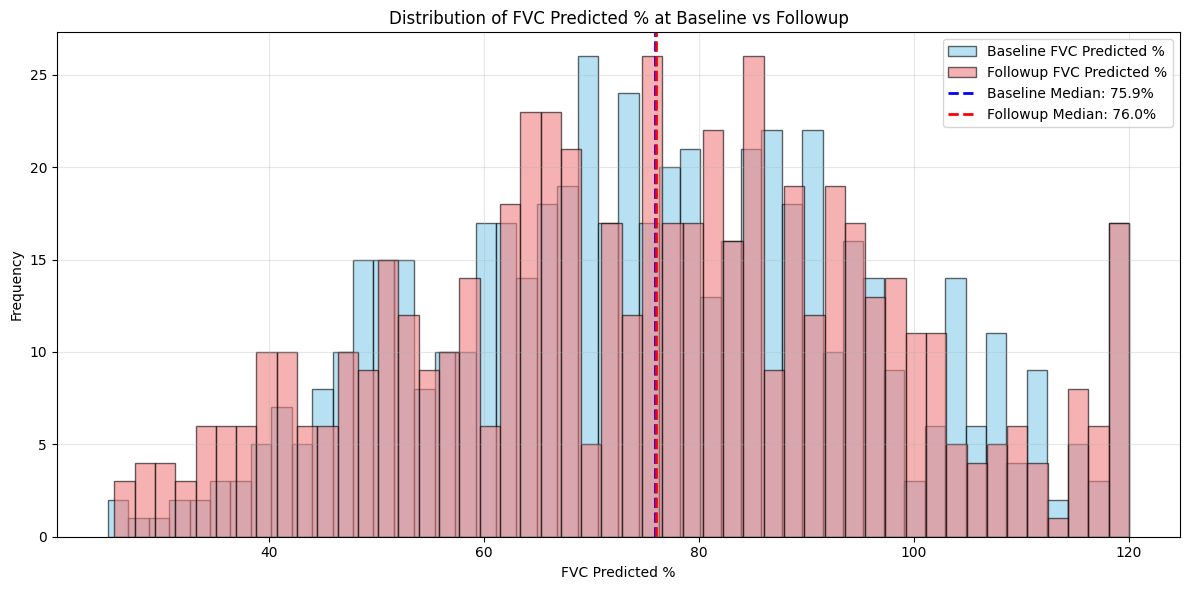

In [33]:
# Plot FVC Predicted distribution at baseline and followup
plt.figure(figsize=(12, 6))

# Plot baseline FVC Predicted
baseline_data = patient_df_baseline['FVC Predicted %'].dropna()
plt.hist(baseline_data, bins=50, alpha=0.6, 
    color='skyblue', label='Baseline FVC Predicted %', edgecolor='black')

# Plot followup FVC Predicted
followup_data = patient_df_followup['FVC Predicted %'].dropna()
plt.hist(followup_data, bins=50, alpha=0.6, 
    color='lightcoral', label='Followup FVC Predicted %', edgecolor='black')

# Add median lines
baseline_median = baseline_data.median()
followup_median = followup_data.median()

plt.axvline(baseline_median, color='blue', linestyle='--', linewidth=2, 
          label=f'Baseline Median: {baseline_median:.1f}%')
plt.axvline(followup_median, color='red', linestyle='--', linewidth=2, 
          label=f'Followup Median: {followup_median:.1f}%')

plt.xlabel('FVC Predicted %')
plt.ylabel('Frequency')
plt.title('Distribution of FVC Predicted % at Baseline vs Followup')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

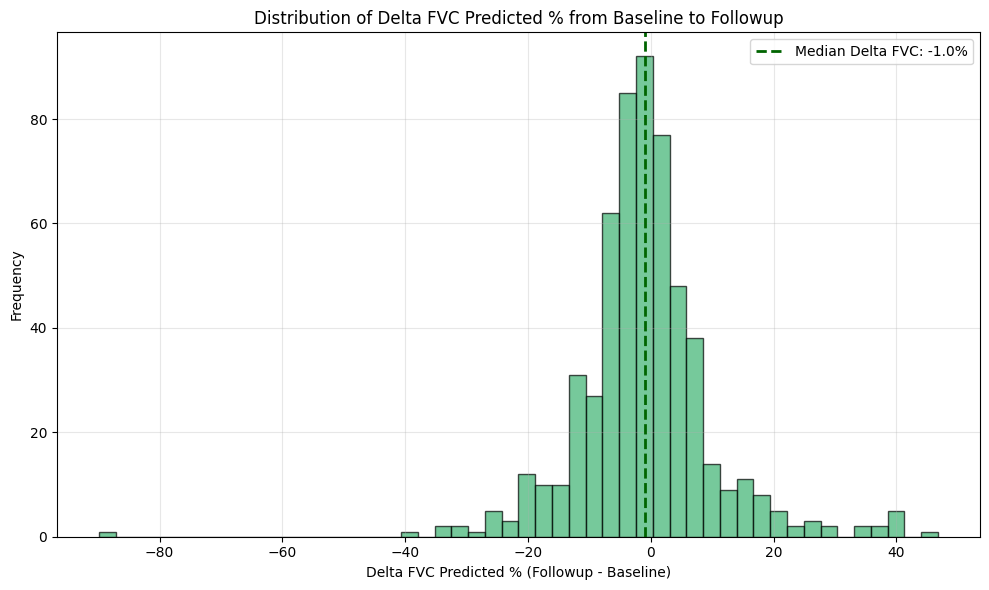

In [34]:
# Plot of delta FVC Predicted from baseline to followup
common_patients = patient_df_baseline.index.intersection(patient_df_followup.index) # just in case
delta_fvc = patient_df_followup.loc[common_patients, 'FVC Predicted %'] - patient_df_baseline.loc[common_patients, 'FVC Predicted %']
delta_fvc = delta_fvc.dropna()
plt.figure(figsize=(10, 6))
plt.hist(delta_fvc, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.axvline(delta_fvc.median(), color='darkgreen', linestyle='--', linewidth=2, 
          label=f'Median Delta FVC: {delta_fvc.median():.1f}%')
plt.xlabel('Delta FVC Predicted % (Followup - Baseline)')
plt.ylabel('Frequency')
plt.title('Distribution of Delta FVC Predicted % from Baseline to Followup')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Some Correlations Checks

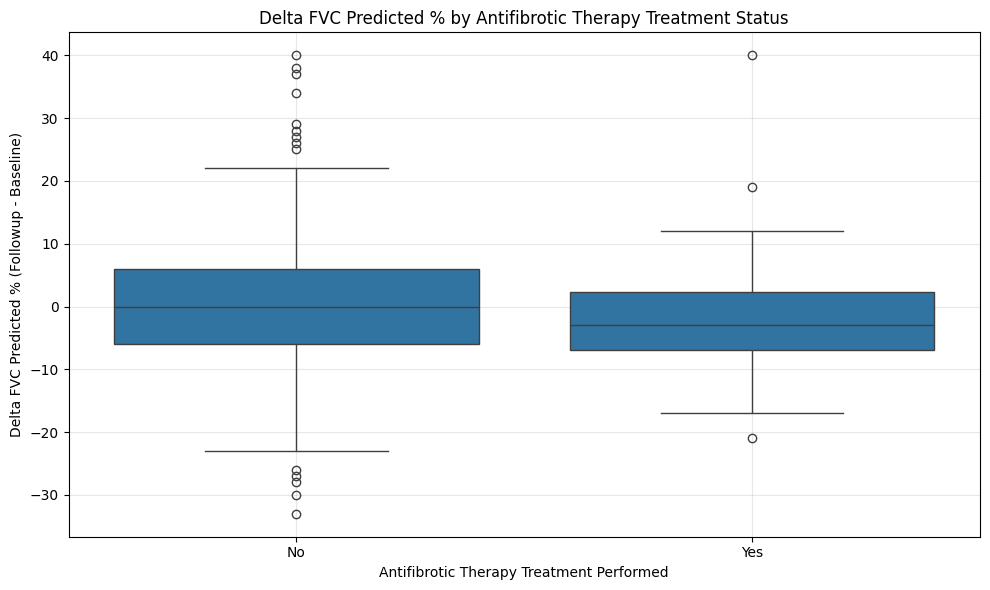

Correlation between Delta FVC Predicted % and Antifibrotic Therapy Treatment: -0.095


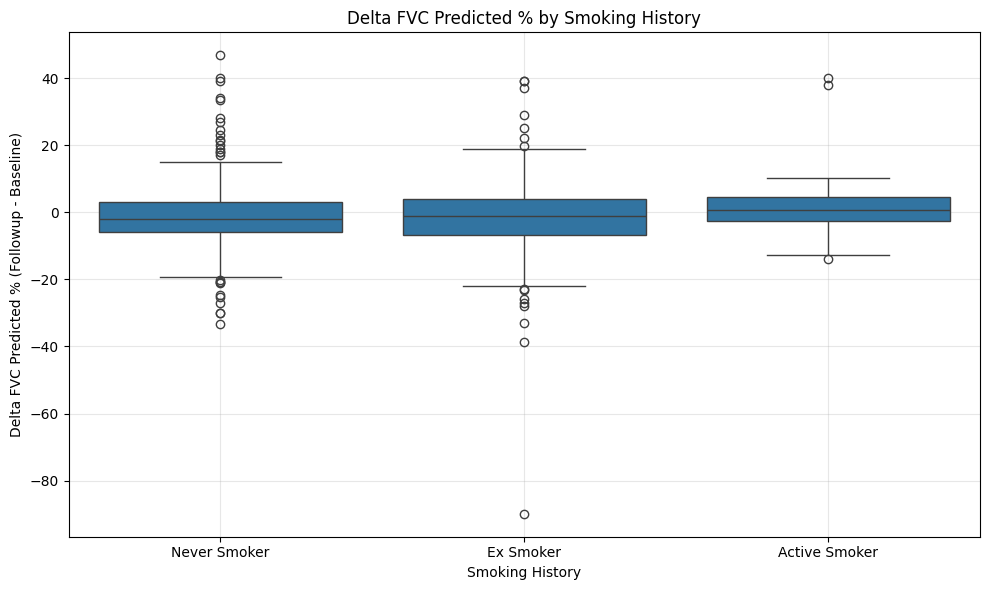

Correlation between Delta FVC Predicted % and Smoking History: 0.020


In [35]:
# corelate delta FVC with treatment 
treatment_status = patient_df_baseline.loc[common_patients, 'Antifibrotic therapy Treatment Performed']
delta_fvc_df = pd.DataFrame({'Delta FVC Predicted %': delta_fvc, 'Antifibrotic Therapy Treatment Performed': treatment_status})
plt.figure(figsize=(10, 6))
sns.boxplot(x='Antifibrotic Therapy Treatment Performed', y='Delta FVC Predicted %', data=delta_fvc_df)
plt.title('Delta FVC Predicted % by Antifibrotic Therapy Treatment Status')
plt.xlabel('Antifibrotic Therapy Treatment Performed')
plt.ylabel('Delta FVC Predicted % (Followup - Baseline)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# corelation coefficient
correlation = delta_fvc_df['Delta FVC Predicted %'].corr(
    delta_fvc_df['Antifibrotic Therapy Treatment Performed'].map({'Yes': 1, 'No': 0}))
print(f'Correlation between Delta FVC Predicted % and Antifibrotic Therapy Treatment: {correlation:.3f}')

#correlate delta FVC with Smoking History
smoking_status = patient_df_baseline.loc[common_patients, 'Smoking History']
delta_fvc_smoking_df = pd.DataFrame({'Delta FVC Predicted %': delta_fvc, 'Smoking History': smoking_status})
plt.figure(figsize=(10, 6))
sns.boxplot(x='Smoking History', y='Delta FVC Predicted %', data=delta_fvc_smoking_df)
plt.title('Delta FVC Predicted % by Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Delta FVC Predicted % (Followup - Baseline)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# corelation coefficient
correlation_smoking = delta_fvc_smoking_df['Delta FVC Predicted %'].corr(
    delta_fvc_smoking_df['Smoking History'].map({'Never Smoker': 0, 'Ex Smoker': 1, 'Active Smoker': 2}))
print(f'Correlation between Delta FVC Predicted % and Smoking History: {correlation_smoking:.3f}')

### Create Datadrame for Regression Modeling

In [36]:
regression_df = patient_df_baseline.merge(
    patient_df_followup[['FVC Predicted %','DLCO(Not Adjusted) Predicted %', 'Week FVC First Acquisition']],
    left_index=True, right_index=True, suffixes=('_Baseline', '_Followup')
)

In [37]:
regression_df

,Age,FVC Predicted %_Baseline,FVC DATE,FVC Volume L,Ethnicity,Race,Home Region,Sex,Research : Height,ImmunomodulationTherepy Treatment Performed,...,Risk Precipitins,DLCO(Not Adjusted) Predicted %_Baseline,DLCO CAP(Not Adjusted),DLCO DATE(Not Adjusted),FVC Week,First Acquisition Date,Week FVC First Acquisition_Baseline,FVC Predicted %_Followup,DLCO(Not Adjusted) Predicted %_Followup,Week FVC First Acquisition_Followup
Subject ID,,,,,,,,,,,,,,,,,,,,,
100922,77.0,78.0,1976-09-27,1.49,None,None,Western Europe,Female,0.00,No,...,No,NaN,NaN,None,0.0,1976-09-27,0,92.0,NaN,53
100992,None,97.0,1969-10-06,2.18,None,None,Western Europe,Female,0.00,None,...,No,NaN,NaN,None,0.0,1969-10-06,0,94.0,NaN,55
102083,None,51.0,1949-10-31,1.27,None,None,Western Europe,Female,0.00,Yes,...,No,NaN,NaN,None,0.0,1949-10-31,0,46.5,NaN,53
111522,None,86.0,1967-10-09,2.88,None,None,Western Europe,Male,0.00,No,...,No,NaN,NaN,None,0.0,1967-10-09,0,86.0,NaN,48
115616,None,116.0,1976-09-27,3.11,None,None,Western Europe,Female,0.00,No,...,No,NaN,NaN,None,0.0,1976-09-27,0,110.0,NaN,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006455,63.0,80.0,1962-05-01,3.15,Hispanic or Latino,Multi-Racial,North America,Female,177.80,None,...,None,57.0,15.88,'1963-02-01',4.0,1962-05-01,0,84.0,68.0,52
1006459,66.0,78.0,1966-05-01,2.75,Not Hispanic or Latino,White,North America,Male,161.60,None,...,None,46.0,12.06,'1966-08-01',4.0,1966-05-01,0,59.0,74.0,52
1006781,54.0,73.0,1952-10-01,2.93,Not Hispanic or Latino,White,North America,Male,164.30,None,...,None,102.0,24.45,'1954-04-01',4.0,1952-10-01,0,77.0,94.0,52


In [38]:
nan_count_reg = regression_df.isnull().sum()
print("NaN counts per column in regression dataframe:")
print(nan_count_reg.sort_values(ascending=False))

NaN counts per column in regression dataframe:
Secondary Diagnosis                            561
Risk Occupational Description                  521
Cause of Death                                 517
Smoking Stop Date                              443
General Therapy Treatment Performed            419
Antifibrotic therapy Treatment Performed       417
ImmunomodulationTherepy Treatment Performed    415
Smoking Pack Years                             391
Finger Clubbing                                343
Risk Precipitins                               334
Cough                                          333
Velcro Crackles                                332
Risk Environmental                             329
Dyspnea                                        325
DLCO(Not Adjusted) Predicted %_Followup        305
Race                                           302
DLCO(Not Adjusted) Predicted %_Baseline        300
Ethnicity                                      282
Familial Pulm Fibrosis             

In [39]:
# Save regression dataframe for further analysis
regression_df.to_csv('./df_regression_analysis.csv', index=True)